In [1]:
import polars as pl
import altair as alt
import pyarrow as pa
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

alt.data_transformers.enable("vegafusion")
plt.style.use('seaborn-v0_8-whitegrid')

df = pl.read_parquet("../data/processed/aemet_clean.parquet")
df_pd = df.to_pandas()

In [2]:
prov_map = {
    'Illes Balears': 'ILLES BALEARS',
    'Asturias': 'ASTURIAS',
    'A Coruña': 'A CORUÑA',
    'Girona': 'GIRONA',
    'Las Palmas': 'LAS PALMAS',
    'Pontevedra': 'PONTEVEDRA',
    'Santa Cruz De Tenerife': 'SANTA CRUZ DE TENERIFE',
    'Cantabria': 'CANTABRIA',
    'Málaga': 'MALAGA',
    'Almería': 'ALMERIA',
    'Murcia': 'MURCIA',
    'Albacete': 'ALBACETE',
    'Ávila': 'AVILA',
    'Araba/Álava': 'ARABA/ALAVA',
    'Badajoz': 'BADAJOZ',
    'Alacant/Alicante': 'ALICANTE',
    'Ourense': 'OURENSE',
    'Barcelona': 'BARCELONA',
    'Burgos': 'BURGOS',
    'Cáceres': 'CACERES',
    'Cádiz': 'CADIZ',
    'Castelló/Castellón': 'CASTELLON',
    'Ciudad Real': 'CIUDAD REAL',
    'Jaén': 'JAEN',
    'Córdoba': 'CORDOBA',
    'Cuenca': 'CUENCA',
    'Granada': 'GRANADA',
    'Guadalajara': 'GUADALAJARA',
    'Gipuzkoa/Guipúzcoa': 'GIPUZKOA',
    'Huelva': 'HUELVA',
    'Huesca': 'HUESCA',
    'León': 'LEON',
    'Lleida': 'LLEIDA',
    'La Rioja': 'LA RIOJA',
    'Soria': 'SORIA',
    'Navarra': 'NAVARRA',
    'Ceuta': 'CEUTA',
    'Lugo': 'LUGO',
    'Madrid': 'MADRID',
    'Palencia': 'PALENCIA',
    'Salamanca': 'SALAMANCA',
    'Segovia': 'SEGOVIA',
    'Sevilla': 'SEVILLA',
    'Toledo': 'TOLEDO',
    'Tarragona': 'TARRAGONA',
    'Teruel': 'TERUEL',
    'València/Valencia': 'VALENCIA',
    'Valladolid': 'VALLADOLID',
    'Bizkaia/Vizcaya': 'BIZKAIA',
    'Zamora': 'ZAMORA',
    'Zaragoza': 'ZARAGOZA',
    'Melilla': 'MELILLA',
}

In [3]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]


### 1.1. Mapa de calor — Temperatura media: provincia × mes

**Tipo:** Mapa de calor (heatmap)
**Datos:** Temperatura promedio por provincia y mes


In [8]:
heatmap_data = (df_pd
    .groupby(["provincia", "mes"])["temperatura_media"]
    .mean()
    .reset_index()
    .rename(columns={"temperatura_media": "temp_mean"})
)

alt.Chart(heatmap_data).mark_rect().encode(
    x=alt.X("mes:N", title="Month", sort=list(month_order)),
    y=alt.Y("provincia:N", title="Province"),
    color=alt.Color("temp_mean:Q", title="Avg Temp (C)",
                    scale=alt.Scale(scheme="redyellowblue", reverse=True)),
    tooltip=["provincia", "mes", alt.Tooltip("temp_mean", format=".1f")]
).properties(
    title="Average Temperature: Province x Month",
    width=600,
    height=600
).interactive().show()

alt.Chart(...)

### 1.2. Mapa de calor — Precipitación media: provincia × mes

**Tipo:** Mapa de calor (heatmap)
**Datos:** Precipitación promedio por provincia y mes


In [ ]:
heatmap_precip_mean = (df_pd
    .group_by(["provincia", "mes"])
    .agg(pl.col("precipitacion").mean().alias("precip_mean"))
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
)

alt.Chart(heatmap_precip_mean).mark_rect().encode(
    x=alt.X("mes:N", title="Month", sort=list(month_order)),
    y=alt.Y("provincia:N", title="Province"),
    color=alt.Color("precip_mean:Q", title="Avg Precipitation (mm)",
                    scale=alt.Scale(scheme="blues", reverse=True)),
    tooltip=["provincia", "mes", alt.Tooltip("precip_mean", format=".1f")]
).properties(
    title="Average Precipitation: Province x Month",
    width=600,
    height=600
).interactive().show()


alt.Chart(...)

### 1.3. Mapa de calor — Velocidad del viento media: provincia × mes

**Tipo:** Mapa de calor (heatmap)
**Datos:** Velocidad del viento promedio por provincia y mes


In [ ]:
heatmap_viento_mean = (df_pd
    .group_by(["provincia", "mes"])
    .agg(pl.col("velocidad_viento_media").mean().alias("viento_mean"))
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
)

alt.Chart(heatmap_viento_mean).mark_rect().encode(
    x=alt.X("mes:N", title="Month", sort=list(month_order)),
    y=alt.Y("provincia:N", title="Province"),
    color=alt.Color("viento_mean:Q", title="Avg Wind Speed (m/s)",
                    scale=alt.Scale(scheme="greens", reverse=True)),
    tooltip=["provincia", "mes", alt.Tooltip("viento_mean", format=".1f")]
).properties(
    title="Average Wind Speed: Province x Month",
    width=600,
    height=600
).interactive().show()


alt.Chart(...)

### 1.4. Diagrama de dispersión — Temperatura vs Precipitación

**Tipo:** Scatter plot con selector interactivo por provincia
**Datos:** Relación temperatura/precipitación. Selecciona una provincia. Color = mes. Cada punto = un mes.


In [10]:
scatter_precip = (df
    .group_by(["mes", "provincia"])
    .agg([
        pl.col("temperatura_media").mean().alias("temp_mean"),
        pl.col("precipitacion").mean().alias("precip_mean"),
    ])
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
)


In [14]:
scatter_precip = scatter_precip.with_columns([
    pl.col("provincia").cast(pl.String),
    pl.col("mes").cast(pl.String)
])

prov_list_precip = sorted(scatter_precip["provincia"].unique())

selector_precip = alt.selection_point(
    fields=["provincia"],
    bind=alt.binding_select(options=prov_list_precip, name="Select Province: "),
    value=[{"provincia": prov_list_precip[0]}]
)

alt.Chart(scatter_precip).mark_circle(size=60, opacity=0.7).encode(
    x=alt.X("temp_mean:Q", title="Avg Temperature (C)"),
    y=alt.Y("precip_mean:Q", title="Avg Precipitation (mm)"),
    color=alt.Color("mes:N", title="Month", sort=list(month_order),
                    scale=alt.Scale(scheme="turbo")),
    tooltip=["mes", "provincia",
             alt.Tooltip("temp_mean", format=".1f"),
             alt.Tooltip("precip_mean", format=".2f")]
).add_params(
    selector_precip
).transform_filter(
    selector_precip
).properties(
    title="Temperature vs Precipitation by Province & Month",
    width=600,
    height=400
).interactive().show()


alt.Chart(...)

### 1.5. Diagrama de dispersión — Temperatura vs Velocidad del viento

**Tipo:** Scatter plot con selector interactivo por provincia
**Datos:** Relación temperatura/viento. Selecciona una provincia. Color = mes. Cada punto = un mes.


In [16]:
scatter_viento = (df
    .group_by(["mes", "provincia"])
    .agg([
        pl.col("temperatura_media").mean().alias("temp_mean"),
        pl.col("velocidad_viento_media").mean().alias("viento_mean"),
    ])
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
)


In [19]:
scatter_viento = scatter_viento.with_columns([
    pl.col("provincia").cast(pl.String),
    pl.col("mes").cast(pl.String)
])

prov_list_viento = sorted(scatter_viento["provincia"].unique())

selector_viento = alt.selection_point(
    fields=["provincia"],
    bind=alt.binding_select(options=prov_list_viento, name="Select Province: "),
    value=[{"provincia": prov_list_viento[0]}]
)

alt.Chart(scatter_viento).mark_circle(size=60, opacity=0.7).encode(
    x=alt.X("temp_mean:Q", title="Avg Temperature (C)"),
    y=alt.Y("viento_mean:Q", title="Avg Wind Speed (m/s)"),
    color=alt.Color("mes:N", title="Month", sort=list(month_order),
                    scale=alt.Scale(scheme="turbo")),
    tooltip=["mes", "provincia",
             alt.Tooltip("temp_mean", format=".1f"),
             alt.Tooltip("viento_mean", format=".2f")]
).add_params(
    selector_viento
).transform_filter(
    selector_viento
).properties(
    title="Temperature vs Wind Speed by Province & Month",
    width=600,
    height=400
).interactive().show()


alt.Chart(...)

### 1.6. Mapa de calor — Correlaciones entre variables numéricas

**Tipo:** Mapa de calor (heatmap) de correlaciones
**Datos:** Matriz de correlación entre todas las variables numéricas del dataset AEMET


In [26]:
num_cols = [
    "temperatura_media", "precipitacion", "temperatura_minima",
    "temperatura_maxima", "humedad_relativa_media", "humedad_relativa_maxima",
    "humedad_relativa_minima", "velocidad_viento_media", "racha_maxima_viento"
]

corr_df = df_pd[num_cols].corr().reset_index()
corr_df.columns = ["var1"] + num_cols
corr_melted = corr_df.melt(id_vars="var1", var_name="var2", value_name="corr")

alt.Chart(corr_melted).mark_rect().encode(
    x=alt.X("var1:N", title=""),
    y=alt.Y("var2:N", title=""),
    color=alt.Color("corr:Q", title="Correlation",
                scale=alt.Scale(scheme="rainbow", domain=[-1, 1])),
    tooltip=["var1", "var2", alt.Tooltip("corr", format=".2f")]
).properties(
    title="Correlation Heatmap (Numeric Variables)",
    width=500,
    height=500
).interactive().show()

alt.Chart(...)

### 1.7. Mapas coropléticos de España por provincia

**Tipo:** Mapas coropléticos (choropleth)
**Datos:** Temperatura, precipitación y velocidad del viento promedio por provincia


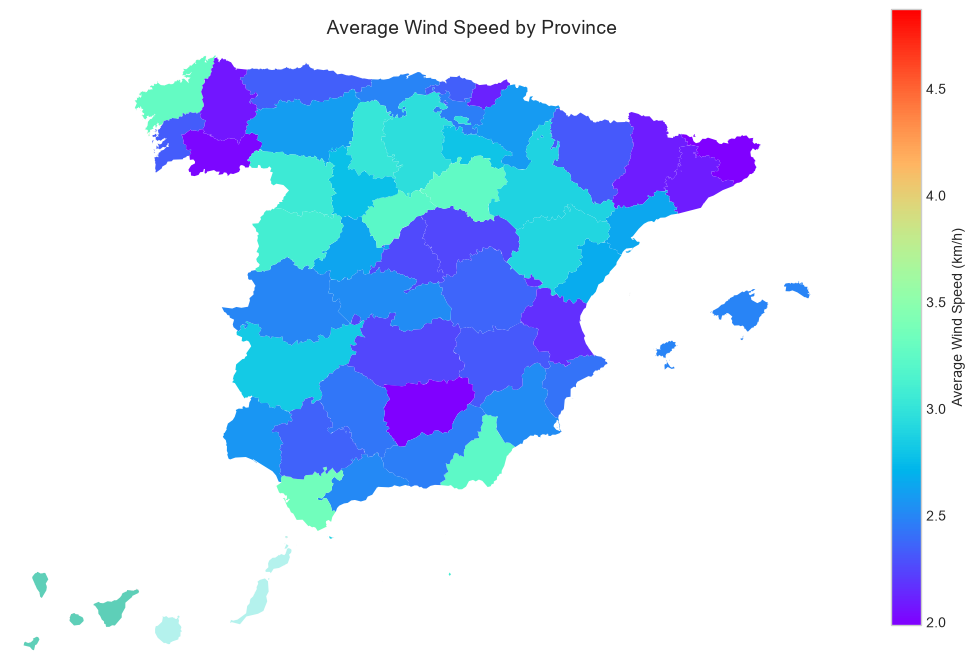

In [29]:
spain = gpd.read_file("https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson")
spain = spain.to_crs(epsg=4326)

spain["provincia"] = spain["name"].map(prov_map)

df_agg = df_pd.groupby("provincia")["velocidad_viento_media"].mean().reset_index()
df_agg.columns = ["provincia", "viento_medio"]

map_df = spain.merge(df_agg, on="provincia")

canarias = map_df[map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]
peninsula = map_df[~map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
map_df.plot(
    column="viento_medio",
    ax=ax,
    legend=True,
    cmap = plt.cm.rainbow,
    legend_kwds={"label": "Average Wind Speed (km/h)"}
)

ax_inset = fig.add_axes([0.05, 0.05, 0.25, 0.2])
canarias.plot(column="viento_medio", ax=ax_inset, cmap=cmap,
    vmin=map_df["viento_medio"].min(), vmax=map_df["viento_medio"].max())
ax_inset.set_axis_off()

ax.set_title("Average Wind Speed by Province", fontsize=14)
ax.set_xlim(-10, 5)
ax.set_ylim(35, 44)
ax.set_axis_off()
plt.show()

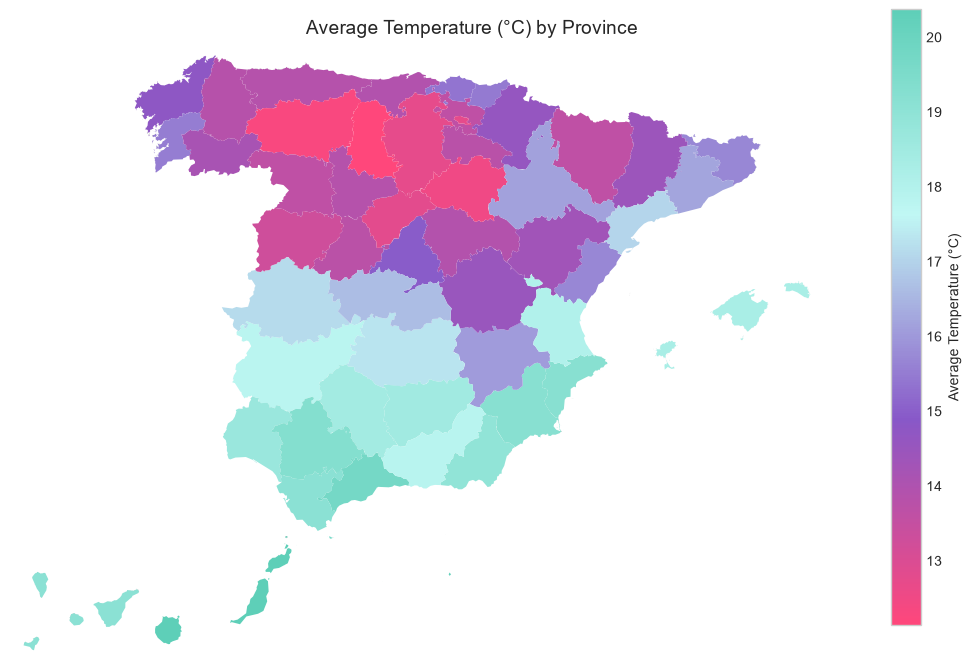

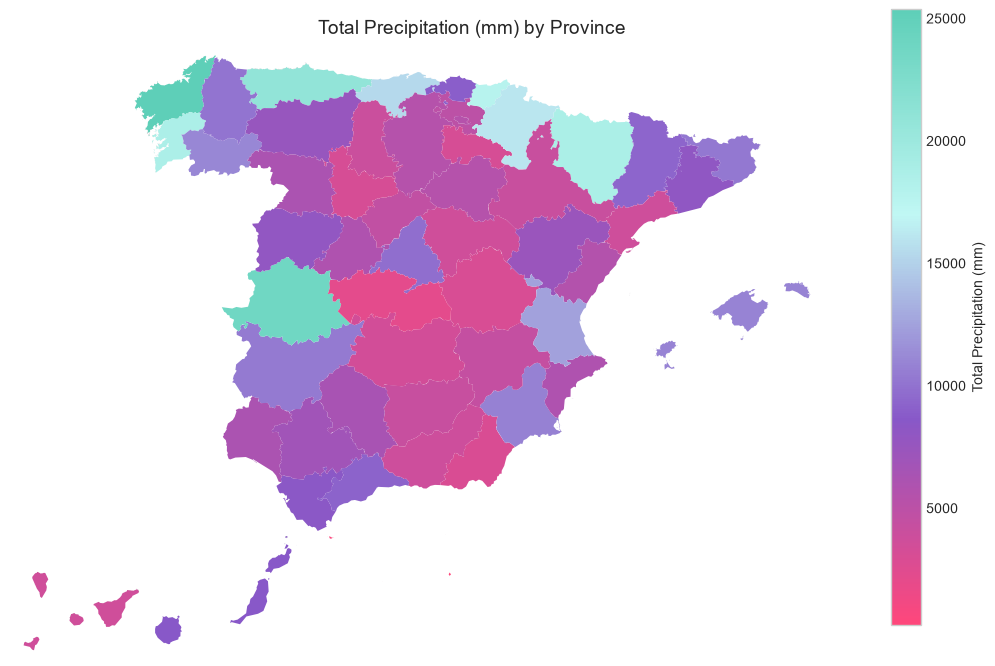

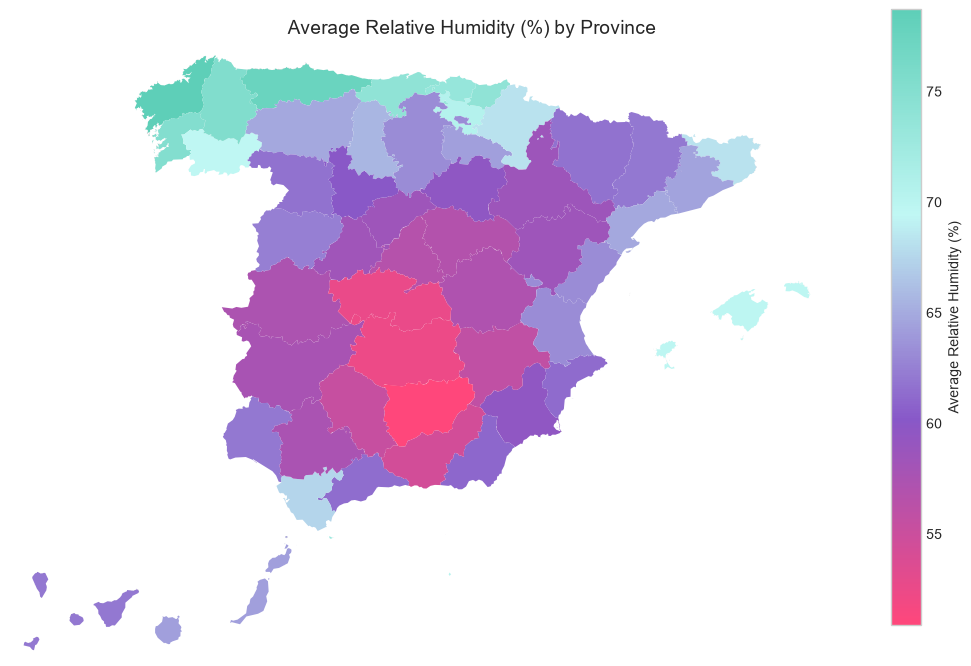

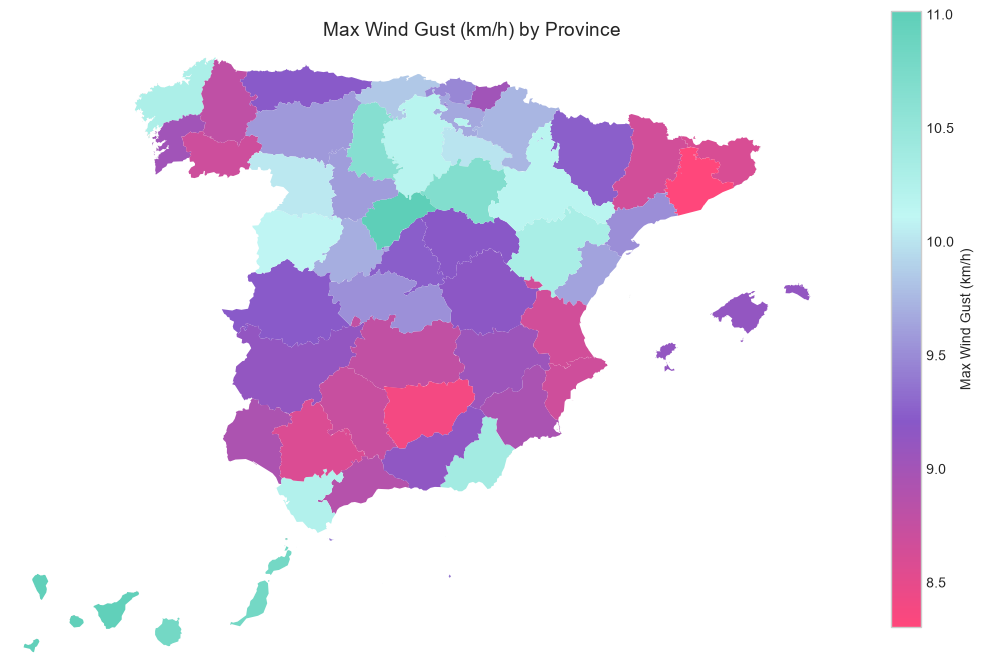

In [30]:
variables = {
    "temperatura_media": "Average Temperature (°C)",
    "precipitacion": "Total Precipitation (mm)",
    "humedad_relativa_media": "Average Relative Humidity (%)",
    "racha_maxima_viento": "Max Wind Gust (km/h)"
}

agg_funcs = {
    "temperatura_media": "mean",
    "precipitacion": "sum",
    "humedad_relativa_media": "mean",
    "racha_maxima_viento": "mean"
}

for var, label in variables.items():

    df_agg = df_pd.groupby("provincia")[var].agg(agg_funcs[var]).reset_index()
    df_agg.columns = ["provincia", "valor"]

    map_df = spain.merge(df_agg, on="provincia")

    canarias = map_df[map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]
    peninsula = map_df[~map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]

    cmap = LinearSegmentedColormap.from_list("custom", ["#FF477B", "#8858C8", "#C0F7F4", "#5ECFB8"])

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    map_df.plot(column="valor", ax=ax, legend=True, cmap=cmap,
        legend_kwds={"label": label})

    ax_inset = fig.add_axes([0.05, 0.05, 0.25, 0.2])
    canarias.plot(column="valor", ax=ax_inset, cmap=cmap,
        vmin=map_df["valor"].min(), vmax=map_df["valor"].max())
    ax_inset.set_axis_off()

    ax.set_title(f"{label} by Province", fontsize=14)
    ax.set_xlim(-10, 5)
    ax.set_ylim(35, 44)
    ax.set_axis_off()
    plt.show()